# Notebook 3 — Modélisation ML : sélection, entraînement & interprétation

## Objectif
À partir des données chargées **directement depuis DuckDB** (`warehouse.duckdb`),
entraîner des modèles de **classification supervisée** pour prédire le **bloc politique
gagnant** par commune.

## Rappel : apprentissage supervisé
L'apprentissage supervisé consiste à entraîner un modèle sur des données **étiquetées**
(ici : les indicateurs socio-économiques = features, le bloc gagnant = label).
Le modèle apprend une fonction de décision à partir d'un **jeu d'entraînement**,
puis sa capacité de généralisation est évaluée sur un **jeu de test** non vu.

## Métrique principale : Accuracy
`accuracy = nombre de prédictions correctes / nombre total de prédictions`  
Le cahier des charges exige une accuracy **> 0.5** (mieux que le hasard sur 4 classes = 0.25).

## 1. Installation des dépendances

In [ ]:
# Installer les librairies nécessaires (exécuter une seule fois)
!pip install mlflow optuna explainerdashboard scikit-learn xgboost lightgbm shap --quiet

## 2. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import mlflow
import mlflow.sklearn

import optuna

from explainerdashboard import ClassifierExplainer, ExplainerDashboard

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print('Toutes les librairies sont chargées.')

d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Toutes les librairies sont chargées.


## 3. Chargement et préparation des données depuis DuckDB

In [2]:
# ============================================================
# ÉTAPE 3.1 : Extraction depuis DuckDB
# Même logique que model.ipynb — toutes les données viennent
# de l'entrepôt warehouse.duckdb produit par l'ETL pipeline
# ============================================================
con = duckdb.connect('warehouse.duckdb')

df_candidats = con.execute('SELECT * FROM fact_candidats_blocs').df()
df_diplomes  = con.execute('SELECT * FROM fact_diplomes').df()
df_emploi    = con.execute('SELECT * FROM fact_emploi_pop_active').df()
df_logement  = con.execute('SELECT * FROM fact_logement').df()
df_revenus   = con.execute('SELECT * FROM fact_revenus').df()
df_t1        = con.execute('SELECT * FROM fact_election_tour1').df()

con.close()

print('Données extraites depuis DuckDB :')
print(f'  fact_candidats_blocs   : {df_candidats.shape}')
print(f'  fact_diplomes          : {df_diplomes.shape}')
print(f'  fact_emploi_pop_active : {df_emploi.shape}')
print(f'  fact_logement          : {df_logement.shape}')
print(f'  fact_revenus           : {df_revenus.shape}')
print(f'  fact_election_tour1    : {df_t1.shape}')

Données extraites depuis DuckDB :
  fact_candidats_blocs   : (267, 12)
  fact_diplomes          : (752, 17)
  fact_emploi_pop_active : (275, 8)
  fact_logement          : (752, 23)
  fact_revenus           : (23, 12)
  fact_election_tour1    : (1317, 25)


In [3]:
# ============================================================
# ÉTAPE 3.2 : Construction des features (même logique que model.ipynb)
# ============================================================

# ── Base électorale ──────────────────────────────────────────
df_base = df_candidats.copy()
df_base['codgeo'] = df_base['codgeo'].astype(str).str.zfill(5)

# Enrichir avec la participation T1
df_part = (
    df_t1.groupby('codgeo')[['inscrits', 'abstentions', 'votants']]
    .sum().reset_index()
)
df_part['taux_participation_t1'] = (df_part['votants'] / df_part['inscrits']).round(4)
df_part['taux_abstention_t1']    = (df_part['abstentions'] / df_part['inscrits']).round(4)
df_part['codgeo'] = df_part['codgeo'].astype(str).str.zfill(5)
df_base = df_base.merge(df_part[['codgeo', 'inscrits', 'taux_participation_t1', 'taux_abstention_t1']],
                        on='codgeo', how='left')

# ── Diplômes ─────────────────────────────────────────────────
df_dipl = df_diplomes.groupby('codgeo')[['pop_15_non_scolarise', 'sans_diplme', 'brevet',
                                         'cap_bep', 'bac', 'bac_2', 'bac_3_4', 'bac_5_et']].sum().reset_index()
df_dipl['codgeo'] = df_dipl['codgeo'].astype(str).str.zfill(5)
base_dipl = df_dipl['pop_15_non_scolarise'].replace(0, np.nan)
df_dipl['pct_sans_diplome'] = (df_dipl['sans_diplme'] / base_dipl).round(4)
df_dipl['pct_brevet']       = (df_dipl['brevet']      / base_dipl).round(4)
df_dipl['pct_cap_bep']      = (df_dipl['cap_bep']     / base_dipl).round(4)
df_dipl['pct_bac']          = (df_dipl['bac']         / base_dipl).round(4)
df_dipl['pct_bac_plus2']    = (df_dipl['bac_2']       / base_dipl).round(4)
df_dipl['pct_bac_plus5']    = (df_dipl['bac_5_et']    / base_dipl).round(4)
df_dipl = df_dipl[['codgeo'] + [c for c in df_dipl.columns if c.startswith('pct_')]]

# ── Emploi ───────────────────────────────────────────────────
df_emp = df_emploi.copy()
df_emp['codgeo'] = df_emp['codgeo'].astype(str).str.zfill(5)
df_emp['part_15_24']  = (df_emp['pop_15_24_ans']     / df_emp['pop_15_64_ans']).round(4)
df_emp['part_55_64']  = (df_emp['pop_55_64_ans']     / df_emp['pop_15_64_ans']).round(4)
df_emp['ratio_femmes']= (df_emp['femmes_15_64_ans']  / df_emp['pop_15_64_ans']).round(4)
df_emp = df_emp[['codgeo', 'pop_15_64_ans', 'part_15_24', 'part_55_64', 'ratio_femmes']]

# ── Logement ─────────────────────────────────────────────────
cols_log = ['nb_total_de_logements', 'résidences_principales', 'résidences_secondaires',
            'logements_vacants', 'maison', 'appart', 'nb_de_ménages',
            'propriétaires', 'locataires', 'logements_sociaux_hlm',
            'ménages_avec_1_voiture', 'ménages_avec_2_voitures_ou_']
cols_log = [c for c in cols_log if c in df_logement.columns]
df_log = df_logement.groupby('codgeo')[cols_log].sum().reset_index()
df_log['codgeo'] = df_log['codgeo'].astype(str).str.zfill(5)
base_log = df_log['nb_total_de_logements'].replace(0, np.nan)
base_rp  = df_log['résidences_principales'].replace(0, np.nan)
df_log['pct_proprietaires'] = (df_log['propriétaires'] / base_rp).round(4)
df_log['pct_locataires']    = (df_log['locataires']    / base_rp).round(4)
df_log['pct_hlm']           = (df_log['logements_sociaux_hlm'] / base_rp).round(4)
df_log['pct_maisons']       = (df_log['maison']  / base_log).round(4)
df_log['pct_apparts']       = (df_log['appart']  / base_log).round(4)
df_log['pct_vacants']       = (df_log['logements_vacants'] / base_log).round(4)
df_log['pct_2_voitures']    = (df_log['ménages_avec_2_voitures_ou_'] / base_rp).round(4)
df_log = df_log[['codgeo'] + [c for c in df_log.columns if c.startswith('pct_')]]

# ── Revenus ──────────────────────────────────────────────────
df_rev = df_revenus.copy()
df_rev['codgeo'] = df_rev['codgeo'].astype(str).str.zfill(5)
rename_map = {}
for col in df_rev.columns:
    if 'médian' in col.lower(): rename_map[col] = 'revenu_median'
    elif 'pauvreté' in col.lower(): rename_map[col] = 'taux_pauvrete'
df_rev = df_rev.rename(columns=rename_map)
cols_rev = ['codgeo'] + [c for c in ['revenu_median', 'taux_pauvrete'] if c in df_rev.columns]
df_rev = df_rev[cols_rev]

print('Features construites.')

Features construites.


In [4]:
# ============================================================
# ÉTAPE 3.3 : Fusion du dataset final
# ============================================================
df = df_base.merge(df_dipl, on='codgeo', how='left')
df = df.merge(df_emp,  on='codgeo', how='left')
df = df.merge(df_log,  on='codgeo', how='left')
df = df.merge(df_rev,  on='codgeo', how='left')
df = df.replace([np.inf, -np.inf], np.nan)

print(f'Dataset final : {df.shape[0]} communes × {df.shape[1]} colonnes')
print(f'\nVariable cible :')
print(df['bloc_gagnant'].value_counts())
df.head()

Dataset final : 267 communes × 35 colonnes

Variable cible :
bloc_gagnant
Extreme_Droite    138
Centre            100
Gauche             29
Name: count, dtype: int64


,codgeo,Centre,Droite,Extreme_Droite,Gauche,bloc_gagnant,total_voix,pct_Gauche,pct_Centre,pct_Droite,...,pct_proprietaires,pct_locataires,pct_hlm,pct_maisons,pct_apparts,pct_vacants,pct_2_voitures,revenu_median,revenu_median,taux_pauvrete
0,69001,75,17,121,37,Extreme_Droite,250,14.80,30.00,6.80,...,0.8975,0.0896,0.0257,0.9771,0.0229,0.0688,0.7151,NaN,NaN,NaN
1,69002,56,15,64,18,Extreme_Droite,153,11.76,36.60,9.80,...,0.8389,0.1370,0.0236,0.9230,0.0719,0.1814,0.4803,NaN,NaN,NaN
2,69003,501,88,421,406,Centre,1416,28.67,35.38,6.21,...,0.5646,0.4236,0.2108,0.4848,0.5118,0.0795,0.4422,NaN,NaN,NaN
3,69004,120,25,148,96,Extreme_Droite,389,24.68,30.85,6.43,...,0.8231,0.1355,0.0492,0.8708,0.1049,0.0904,0.5851,NaN,NaN,NaN
4,69005,96,24,168,54,Extreme_Droite,342,15.79,28.07,7.02,...,0.8226,0.1613,0.0000,0.8825,0.1138,0.0676,0.6500,NaN,NaN,NaN


In [5]:
print(df.columns[df.columns.duplicated()].tolist())

['revenu_median']


In [6]:
df = df.loc[:, ~df.columns.duplicated()].copy()

In [7]:
# ============================================================
# ÉTAPE 3.4 : Sélection des features
# On exclut : identifiants, voix/% par bloc (fuite de données), variable cible
# ============================================================
cols_exclure = ['codgeo', 'bloc_gagnant', 'total_voix', 'annee']
for col in df.columns:
    if any(b in col for b in ['Gauche', 'Centre', 'Droite', 'Extreme']):
        cols_exclure.append(col)

features = [col for col in df.columns
            if col not in cols_exclure and df[col].dtype in ['float64', 'int64', 'float32', 'int32']]

print(f'Features sélectionnées ({len(features)}) :')
for f in features:
    print(f'  - {f}')

X = df[features].copy()
y = df['bloc_gagnant'].copy()

Features sélectionnées (22) :
  - inscrits
  - taux_participation_t1
  - taux_abstention_t1
  - pct_sans_diplome
  - pct_brevet
  - pct_cap_bep
  - pct_bac
  - pct_bac_plus2
  - pct_bac_plus5
  - pop_15_64_ans
  - part_15_24
  - part_55_64
  - ratio_femmes
  - pct_proprietaires
  - pct_locataires
  - pct_hlm
  - pct_maisons
  - pct_apparts
  - pct_vacants
  - pct_2_voitures
  - revenu_median
  - taux_pauvrete


In [8]:
# ============================================================
# ÉTAPE 3.5 : Encodage de la variable cible
# ============================================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Mapping des classes :')
for i, classe in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f'  {i} → {classe} ({count} communes)')

Mapping des classes :
  0 → Centre (100 communes)
  1 → Extreme_Droite (138 communes)
  2 → Gauche (29 communes)


In [9]:
# ============================================================
# ÉTAPE 3.6 : Gestion des valeurs manquantes
# ============================================================
print(f'Valeurs manquantes dans X : {X.isnull().sum().sum()}')

# Supprimer les colonnes avec >40% de manquantes
X = X.loc[:, X.isna().mean() < 0.40]
X = X.loc[:, X.nunique(dropna=True) > 1]

# Imputer par la médiane
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())
    print('→ Imputées par la médiane')

features = X.columns.tolist()
print(f'Features retenues après filtrage : {len(features)}')

Valeurs manquantes dans X : 530
→ Imputées par la médiane
Features retenues après filtrage : 20


In [34]:
# ============================================================
# ÉTAPE 3.7 : Split train / test (80/20 stratifié)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.33,
    random_state=42,
    stratify=y_encoded
)

print(f'Train : {X_train.shape[0]} communes')
print(f'Test  : {X_test.shape[0]} communes')
print(f'\nDistribution dans le train :')
for i, classe in enumerate(le.classes_):
    print(f'  {classe}: {(y_train == i).sum()}')

Train : 178 communes
Test  : 89 communes

Distribution dans le train :
  Centre: 67
  Extreme_Droite: 92
  Gauche: 19


In [35]:
# ============================================================
# ÉTAPE 3.8 : Normalisation (pour les modèles sensibles à l'échelle)
# ============================================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=features, index=X_test.index)

print('Données normalisées (StandardScaler).')

Données normalisées (StandardScaler).


## 4. Entraînement de plusieurs modèles avec MLflow

In [36]:
# ============================================================
# ÉTAPE 4.1 : Configurer MLflow
# ============================================================
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('electio_analytics_classification')

print('MLflow configuré.')
print("Après exécution, lancez 'mlflow ui' dans le terminal pour voir les résultats.")

MLflow configuré.
Après exécution, lancez 'mlflow ui' dans le terminal pour voir les résultats.


In [37]:
# ============================================================
# ÉTAPE 4.2 : Définir les 6 modèles à tester
# ============================================================
modeles = {
    'Logistic_Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'scaled': True
    },
    'KNN': {
        'model': KNeighborsClassifier(n_neighbors=5),
        'scaled': True
    },
    'Random_Forest': {
        'model': RandomForestClassifier(n_estimators=100, random_state=42),
        'scaled': False
    },
    'Gradient_Boosting': {
        'model': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'scaled': False
    },
    'XGBoost': {
        'model': XGBClassifier(n_estimators=100, random_state=42,
                               use_label_encoder=False, eval_metric='mlogloss'),
        'scaled': False
    },
    'LightGBM': {
        'model': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
        'scaled': False
    }
}

print(f'{len(modeles)} modèles à tester :')
for nom in modeles:
    print(f'  - {nom}')

6 modèles à tester :
  - Logistic_Regression
  - KNN
  - Random_Forest
  - Gradient_Boosting
  - XGBoost
  - LightGBM


In [38]:
# ============================================================
# ÉTAPE 4.3 : Entraîner et logger chaque modèle dans MLflow
# ============================================================
resultats = {}

for nom, config in modeles.items():
    print(f"\n{'='*50}")
    print(f'Entraînement : {nom}')

    model = config['model']
    X_tr  = X_train_scaled if config['scaled'] else X_train
    X_te  = X_test_scaled  if config['scaled'] else X_test

    with mlflow.start_run(run_name=nom):
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        acc    = accuracy_score(y_test, y_pred)

        cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')
        cv_mean   = cv_scores.mean()
        cv_std    = cv_scores.std()

        mlflow.log_param('model_type', nom)
        mlflow.log_param('n_features', len(features))
        mlflow.log_param('scaled',     config['scaled'])
        mlflow.log_metric('accuracy_test',   acc)
        mlflow.log_metric('cv_accuracy_mean', cv_mean)
        mlflow.log_metric('cv_accuracy_std',  cv_std)
        mlflow.sklearn.log_model(model, nom)

        resultats[nom] = {
            'accuracy_test': acc,
            'cv_mean':       cv_mean,
            'cv_std':        cv_std,
            'model':         model,
            'y_pred':        y_pred
        }

        print(f'  Accuracy test : {acc:.4f}')
        print(f'  CV accuracy   : {cv_mean:.4f} ± {cv_std:.4f}')

print(f"\n{'='*50}")
print('Tous les modèles entraînés et loggés dans MLflow.')


Entraînement : Logistic_Regression


2026/04/06 13:33:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 13:33:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 13:33:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 13:33:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  Accuracy test : 0.6966
  CV accuracy   : 0.7811 ± 0.0476

Entraînement : KNN
  Accuracy test : 0.7528
  CV accuracy   : 0.7468 ± 0.0777

Entraînement : Random_Forest


2026/04/06 13:33:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 13:33:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Accuracy test : 0.7079
  CV accuracy   : 0.7522 ± 0.0846

Entraînement : Gradient_Boosting


...

  Accuracy test : 0.7079
  CV accuracy   : 0.7411 ± 0.0598

Entraînement : XGBoost


d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:33:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:33:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:33:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:

  Accuracy test : 0.7303
  CV accuracy   : 0.7408 ± 0.0732

Entraînement : LightGBM


2026/04/06 13:34:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 13:34:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Accuracy test : 0.6854
  CV accuracy   : 0.7241 ± 0.0811

Tous les modèles entraînés et loggés dans MLflow.


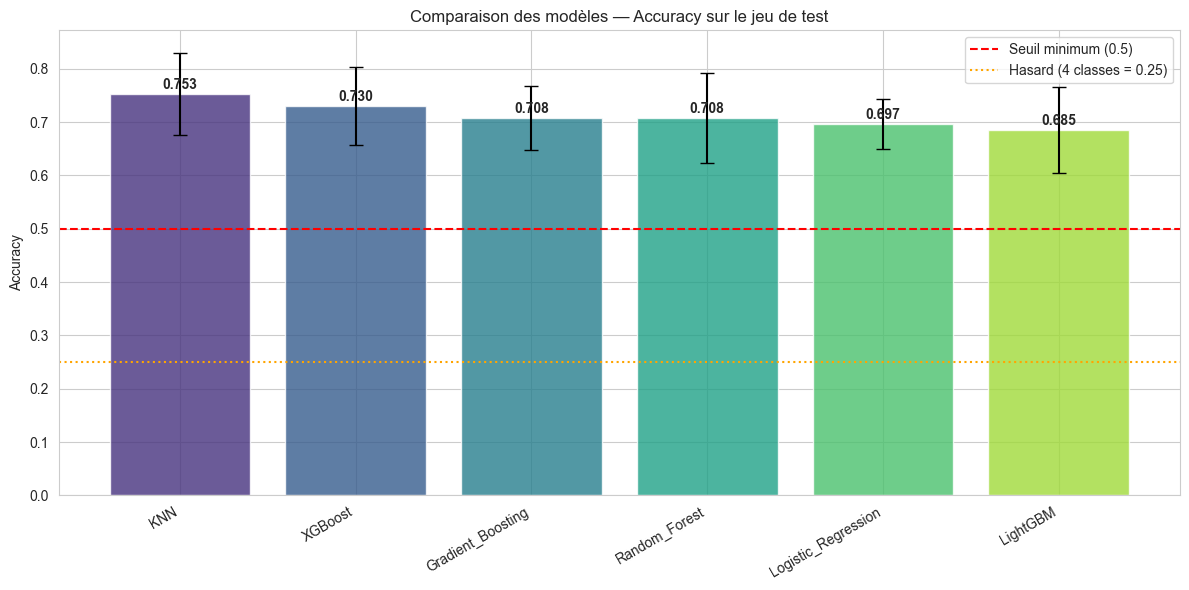


Tableau récapitulatif :
             Modèle  Accuracy Test  CV Mean   CV Std
                KNN       0.752809 0.746825 0.077674
            XGBoost       0.730337 0.740794 0.073153
  Gradient_Boosting       0.707865 0.741111 0.059825
      Random_Forest       0.707865 0.752222 0.084591
Logistic_Regression       0.696629 0.781111 0.047583
           LightGBM       0.685393 0.724127 0.081065


In [39]:
# ============================================================
# GRAPHIQUE 1 : Comparaison des modèles
# ============================================================
df_resultats = pd.DataFrame({
    'Modèle':        list(resultats.keys()),
    'Accuracy Test': [r['accuracy_test'] for r in resultats.values()],
    'CV Mean':       [r['cv_mean']       for r in resultats.values()],
    'CV Std':        [r['cv_std']        for r in resultats.values()]
}).sort_values('Accuracy Test', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x    = range(len(df_resultats))
bars = ax.bar(x, df_resultats['Accuracy Test'],
              yerr=df_resultats['CV Std'], capsize=5,
              color=sns.color_palette('viridis', len(df_resultats)), alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_resultats['Modèle'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Comparaison des modèles — Accuracy sur le jeu de test')
ax.axhline(y=0.5,  color='red',    linestyle='--', label='Seuil minimum (0.5)')
ax.axhline(y=0.25, color='orange', linestyle=':',  label='Hasard (4 classes = 0.25)')
ax.legend()
for bar, acc in zip(bars, df_resultats['Accuracy Test']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
# plt.savefig('graph_11_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTableau récapitulatif :')
print(df_resultats.to_string(index=False))

## 5. Optimisation du meilleur modèle avec Optuna

In [40]:
# ============================================================
# ÉTAPE 5.1 : Identifier le meilleur modèle
# ============================================================
meilleur_nom = max(resultats, key=lambda k: resultats[k]['accuracy_test'])
print(f"Meilleur modèle : {meilleur_nom} (accuracy = {resultats[meilleur_nom]['accuracy_test']:.4f})")

Meilleur modèle : KNN (accuracy = 0.7528)


In [ ]:
# # ============================================================
# # ÉTAPE 5.2 : Fonction objectif Optuna
# # ============================================================
# def objective(trial):
#     if meilleur_nom == 'Random_Forest':
#         params = {
#             'n_estimators':      trial.suggest_int('n_estimators',      50, 500),
#             'max_depth':         trial.suggest_int('max_depth',          3,  20),
#             'min_samples_split': trial.suggest_int('min_samples_split',  2,  20),
#             'min_samples_leaf':  trial.suggest_int('min_samples_leaf',   1,  10),
#             'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#             'random_state': 42
#         }
#         model = RandomForestClassifier(**params)
#         X_tr  = X_train
#     elif meilleur_nom == 'XGBoost':
#         params = {
#             'n_estimators':    trial.suggest_int('n_estimators', 50, 500),
#             'max_depth':       trial.suggest_int('max_depth', 3, 15),
#             'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#             'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
#             'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
#             'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'mlogloss'
#         }
#         model = XGBClassifier(**params)
#         X_tr  = X_train
#     elif meilleur_nom == 'LightGBM':
#         params = {
#             'n_estimators':  trial.suggest_int('n_estimators', 50, 500),
#             'max_depth':     trial.suggest_int('max_depth', 3, 15),
#             'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#             'num_leaves':    trial.suggest_int('num_leaves', 10, 100),
#             'random_state': 42, 'verbose': -1
#         }
#         model = LGBMClassifier(**params)
#         X_tr  = X_train
#     elif meilleur_nom == 'Gradient_Boosting':
#         params = {
#             'n_estimators':  trial.suggest_int('n_estimators', 50, 500),
#             'max_depth':     trial.suggest_int('max_depth', 2, 10),
#             'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#             'random_state': 42
#         }
#         model = GradientBoostingClassifier(**params)
#         X_tr  = X_train
#     else:
#         params = {'C': trial.suggest_float('C', 0.01, 100, log=True), 'max_iter': 2000, 'random_state': 42}
#         model  = LogisticRegression(**params)
#         X_tr   = X_train_scaled

#     scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')
#     return scores.mean()

# ============================================================
# ÉTAPE 5.2 : Fonction objectif Optuna
# ============================================================
def objective(trial):
    if meilleur_nom == 'Random_Forest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42
        }
        model = RandomForestClassifier(**params)
        X_tr = X_train

    elif meilleur_nom == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'use_label_encoder': False,
            'eval_metric': 'mlogloss'
        }
        model = XGBClassifier(**params)
        X_tr = X_train

    elif meilleur_nom == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'random_state': 42,
            'verbose': -1
        }
        model = LGBMClassifier(**params)
        X_tr = X_train

    elif meilleur_nom == 'Gradient_Boosting':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'random_state': 42
        }
        model = GradientBoostingClassifier(**params)
        X_tr = X_train

    elif meilleur_nom == 'KNN':
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 25),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'p': trial.suggest_int('p', 1, 2)
        }
        model = KNeighborsClassifier(**params)
        X_tr = X_train_scaled

    elif meilleur_nom == 'Logistic_Regression':
        params = {
            'C': trial.suggest_float('C', 0.01, 100, log=True),
            'max_iter': 2000,
            'random_state': 42
        }
        model = LogisticRegression(**params)
        X_tr = X_train_scaled

    else:
        raise ValueError(f"Modèle non pris en charge par Optuna : {meilleur_nom}")

    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')
    return scores.mean()

In [53]:
# ============================================================
# ÉTAPE 5.3 : Lancer l'optimisation (100 essais)
# ============================================================
study = optuna.create_study(direction='maximize', study_name='electio_analytics_optuna')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nMeilleure accuracy CV : {study.best_value:.4f}')
print('Meilleurs paramètres :')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

[I 2026-04-06 14:18:07,424] A new study created in memory with name: electio_analytics_optuna
Best trial: 0. Best value: 0.769365:   6%|▌         | 6/100 [00:00<00:03, 24.82it/s]

[I 2026-04-06 14:18:07,488] Trial 0 finished with value: 0.7693650793650794 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,524] Trial 1 finished with value: 0.7522222222222222 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,563] Trial 2 finished with value: 0.7692063492063493 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,593] Trial 3 finished with value: 0.7523809523809525 and parameters: {'n_neighbors': 6, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,633] Trial 4 finished with value: 0.7577777777777778 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,674] Trial 5 finished w

Best trial: 0. Best value: 0.769365:  12%|█▏        | 12/100 [00:00<00:03, 24.92it/s]

[I 2026-04-06 14:18:07,715] Trial 6 finished with value: 0.7634920634920634 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,751] Trial 7 finished with value: 0.741111111111111 and parameters: {'n_neighbors': 24, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,787] Trial 8 finished with value: 0.7692063492063493 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,825] Trial 9 finished with value: 0.7525396825396825 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,871] Trial 10 finished with value: 0.7353968253968254 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7693650793650794.
[I 2026-04-06 14:18:07,912] Trial 11 finishe

Best trial: 12. Best value: 0.774921:  16%|█▌        | 16/100 [00:00<00:03, 23.79it/s]

...

[I 2026-04-06 14:18:11,257] Trial 87 finished with value: 0.7746031746031746 and parameters: {'n_neighbors': 21, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,304] Trial 88 finished with value: 0.7860317460317461 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,347] Trial 89 finished with value: 0.7747619047619049 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,386] Trial 90 finished with value: 0.7577777777777778 and parameters: {'n_neighbors': 22, 'weights': 'uniform', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,428] Trial 91 finished with value: 0.7860317460317461 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.


Best trial: 45. Best value: 0.786032:  96%|█████████▌| 96/100 [00:04<00:00, 23.26it/s]

[I 2026-04-06 14:18:11,468] Trial 92 finished with value: 0.7636507936507936 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,511] Trial 93 finished with value: 0.7860317460317461 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,552] Trial 94 finished with value: 0.7747619047619049 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,595] Trial 95 finished with value: 0.7636507936507936 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,637] Trial 96 finished with value: 0.7860317460317461 and parameters: {'n_neighbors': 24, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.


Best trial: 45. Best value: 0.786032: 100%|██████████| 100/100 [00:04<00:00, 23.03it/s]

[I 2026-04-06 14:18:11,681] Trial 97 finished with value: 0.7803174603174604 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,725] Trial 98 finished with value: 0.7747619047619049 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.
[I 2026-04-06 14:18:11,769] Trial 99 finished with value: 0.7636507936507936 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'p': 2}. Best is trial 45 with value: 0.7860317460317461.

Meilleure accuracy CV : 0.7860
Meilleurs paramètres :
  n_neighbors: 24
  weights: distance
  p: 2


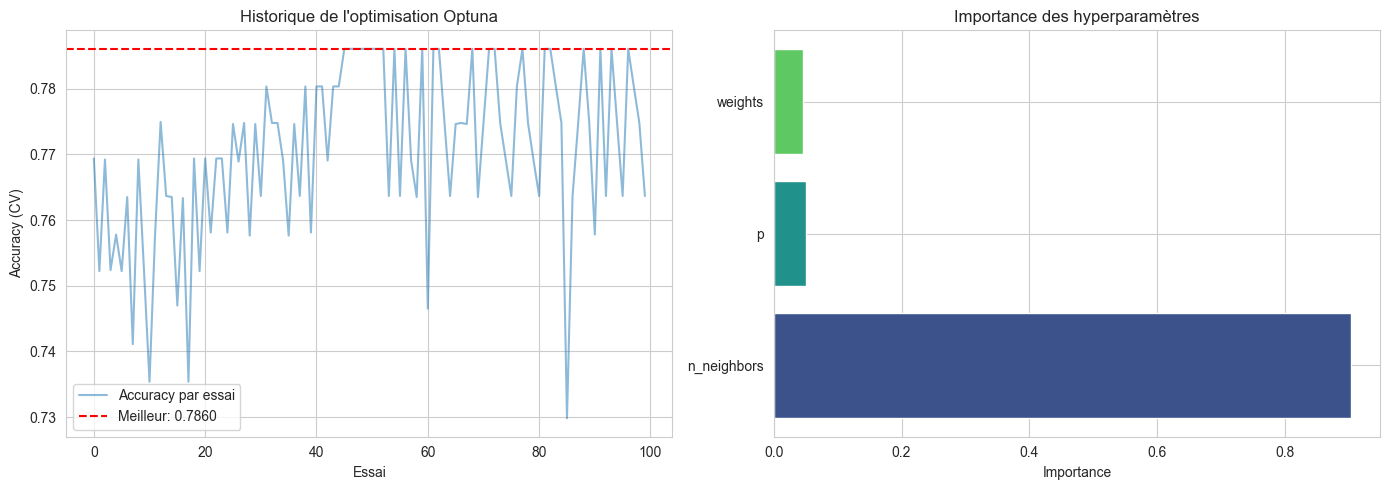

In [54]:
# ============================================================
# GRAPHIQUE 2 : Historique de l'optimisation Optuna
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(values, alpha=0.5, label='Accuracy par essai')
axes[0].axhline(y=study.best_value, color='red', linestyle='--',
                label=f'Meilleur: {study.best_value:.4f}')
axes[0].set_xlabel('Essai')
axes[0].set_ylabel('Accuracy (CV)')
axes[0].set_title("Historique de l'optimisation Optuna")
axes[0].legend()

try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color=sns.color_palette('viridis', len(importances)))
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Importance des hyperparamètres')
except Exception:
    axes[1].text(0.5, 0.5, 'Importance non disponible', ha='center', va='center')

plt.tight_layout()
# plt.savefig('graph_12_optuna_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modèle final avec les meilleurs paramètres

In [56]:
# # ============================================================
# # ÉTAPE 6.1 : Reconstruire et entraîner le modèle optimisé
# # ============================================================
# best_params = study.best_params

# if meilleur_nom == 'Random_Forest':
#     model_final = RandomForestClassifier(**best_params, random_state=42)
#     X_tr_final, X_te_final = X_train, X_test
# elif meilleur_nom == 'XGBoost':
#     model_final = XGBClassifier(**best_params, random_state=42,
#                                 use_label_encoder=False, eval_metric='mlogloss')
#     X_tr_final, X_te_final = X_train, X_test
# elif meilleur_nom == 'LightGBM':
#     model_final = LGBMClassifier(**best_params, random_state=42, verbose=-1)
#     X_tr_final, X_te_final = X_train, X_test
# elif meilleur_nom == 'Gradient_Boosting':
#     model_final = GradientBoostingClassifier(**best_params, random_state=42)
#     X_tr_final, X_te_final = X_train, X_test
# else:
#     model_final = LogisticRegression(**best_params, max_iter=2000, random_state=42)
#     X_tr_final, X_te_final = X_train_scaled, X_test_scaled

# model_final.fit(X_tr_final, y_train)
# y_pred_final = model_final.predict(X_te_final)
# acc_final    = accuracy_score(y_test, y_pred_final)

# print(f'Modèle final : {meilleur_nom} (optimisé par Optuna)')
# print(f"\n{'='*50}")
# print(f"  ACCURACY = {acc_final:.4f}  {'✅ > 0.5' if acc_final > 0.5 else '❌ < 0.5'}")
# print(f"{'='*50}")
# ============================================================
# ÉTAPE 6.1 : Reconstruire et entraîner le modèle optimisé
# ============================================================
best_params = study.best_params

if meilleur_nom == 'Random_Forest':
    model_final = RandomForestClassifier(**best_params, random_state=42)
    X_tr_final, X_te_final = X_train, X_test

elif meilleur_nom == 'XGBoost':
    model_final = XGBClassifier(
        **best_params,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    X_tr_final, X_te_final = X_train, X_test

elif meilleur_nom == 'LightGBM':
    model_final = LGBMClassifier(**best_params, random_state=42, verbose=-1)
    X_tr_final, X_te_final = X_train, X_test

elif meilleur_nom == 'Gradient_Boosting':
    model_final = GradientBoostingClassifier(**best_params, random_state=42)
    X_tr_final, X_te_final = X_train, X_test

elif meilleur_nom == 'KNN':
    model_final = KNeighborsClassifier(**best_params)
    X_tr_final, X_te_final = X_train_scaled, X_test_scaled

elif meilleur_nom == 'Logistic_Regression':
    model_final = LogisticRegression(**best_params, max_iter=2000, random_state=42)
    X_tr_final, X_te_final = X_train_scaled, X_test_scaled

else:
    raise ValueError(f"Modèle non pris en charge dans l'étape 6.1 : {meilleur_nom}")

model_final.fit(X_tr_final, y_train)
y_pred_final = model_final.predict(X_te_final)
acc_final = accuracy_score(y_test, y_pred_final)

print(f"Modèle final : {meilleur_nom} (optimisé par Optuna)")
print(f"\n{'='*50}")
print(f"  ACCURACY = {acc_final:.4f}  {'✅ > 0.5' if acc_final > 0.5 else '❌ < 0.5'}")
print(f"{'='*50}")

Modèle final : KNN (optimisé par Optuna)

  ACCURACY = 0.7191  ✅ > 0.5


In [ ]:
# ============================================================
# ÉTAPE 6.2 : Logger le modèle final dans MLflow
# ============================================================
with mlflow.start_run(run_name=f'{meilleur_nom}_OPTIMISE'):
    mlflow.log_params(best_params)
    mlflow.log_metric('accuracy_test', acc_final)
    mlflow.sklearn.log_model(model_final, f'{meilleur_nom}_optimise')
    print('Modèle final loggé dans MLflow.')

2026/04/06 13:34:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 13:34:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modèle final loggé dans MLflow.


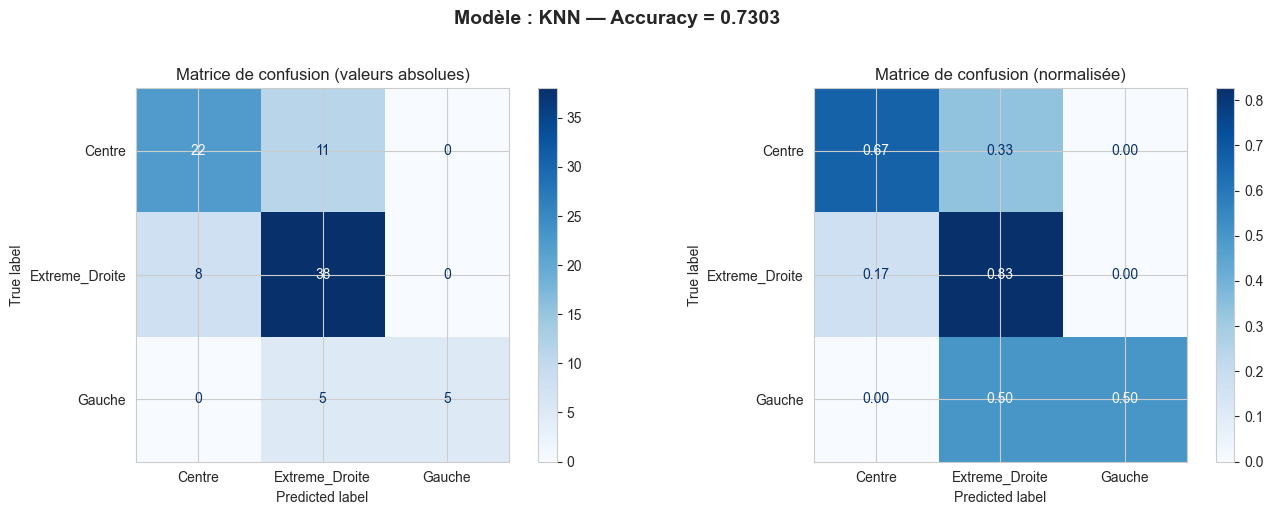

Rapport de classification :
                precision    recall  f1-score   support

        Centre       0.73      0.67      0.70        33
Extreme_Droite       0.70      0.83      0.76        46
        Gauche       1.00      0.50      0.67        10

      accuracy                           0.73        89
     macro avg       0.81      0.66      0.71        89
  weighted avg       0.75      0.73      0.73        89



In [ ]:
# ============================================================
# GRAPHIQUE 3 : Matrice de confusion
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matrice de confusion (valeurs absolues)')

cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=le.classes_).plot(
    ax=axes[1], cmap='Blues', values_format='.2f')
axes[1].set_title('Matrice de confusion (normalisée)')

plt.suptitle(f'Modèle : {meilleur_nom} — Accuracy = {acc_final:.4f}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('graph_13_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rapport de classification :')
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

In [ ]:
# ============================================================
# GRAPHIQUE 4 : Importance des features
# ============================================================
if hasattr(model_final, 'feature_importances_'):
    importances = pd.Series(model_final.feature_importances_, index=features)
    importances = importances.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 8))
    importances.plot(kind='barh', ax=ax,
                     color=sns.color_palette('viridis', len(importances)))
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 15 features les plus importantes — {meilleur_nom}')
    plt.tight_layout()
    # plt.savefig('graph_14_feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nLa donnée la plus corrélée aux résultats électoraux :')
    print(f'  → {importances.idxmax()} (importance = {importances.max():.4f})')

## 7. Interprétabilité avec ExplainerDashboard

In [ ]:
# ============================================================
# ÉTAPE 7.1 : Créer l'ExplainerDashboard
# ============================================================
explainer = ClassifierExplainer(
    model_final,
    X_te_final,
    y_test,
    labels=list(le.classes_)
)

print('Explainer créé avec succès.')
print("Pour lancer le dashboard interactif : ExplainerDashboard(explainer).run()")
print('→ Puis ouvrez http://localhost:8050')

Explainer créé avec succès.
Pour lancer le dashboard interactif : ExplainerDashboard(explainer).run()
→ Puis ouvrez http://localhost:8050


d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\explainerdashboard\explainers.py:425: UserWarning: For shap='linear', shap interaction values cannot be calculated.
d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\explainerdashboard\explainers.py:3235: UserWarning: model_output='probability' is currently not supported for linear classifier models with shap. Defaulting to model_output='logodds'. If you really need probability outputs use shap='kernel' instead.
d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\explainerdashboard\explainers.py:3243: UserWarning: Shap values for shap='linear' are calculated against X_background, but X_background=None, so using X instead...


In [ ]:
# ============================================================
# ÉTAPE 7.2 : Sauvegarder le dashboard en HTML
# ============================================================
db = ExplainerDashboard(explainer, title='Electio-Analytics — Modèle de prédiction électorale')
db.save_html('explainer_dashboard.html')
print('Dashboard sauvegardé : explainer_dashboard.html')

d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\explainerdashboard\dashboards.py:723: UserWarning: Detected notebook environment, consider setting mode='external', mode='inline' or mode='jupyterlab' to keep the notebook interactive while the dashboard is running...
d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\explainerdashboard\dashboards.py:815: UserWarning: For this type of model and model_output interactions don't work, so setting shap_interaction=False...
d:\code mspr\MSPR_BLOC3_MASTER1\venv\Lib\site-packages\explainerdashboard\dashboards.py:822: UserWarning: The explainer object has no decision_trees property, so setting decision_trees=False...


Dashboard sauvegardé : explainer_dashboard.html


## 8. Prédictions prospectives (scénarios à 1, 2, 3 ans)

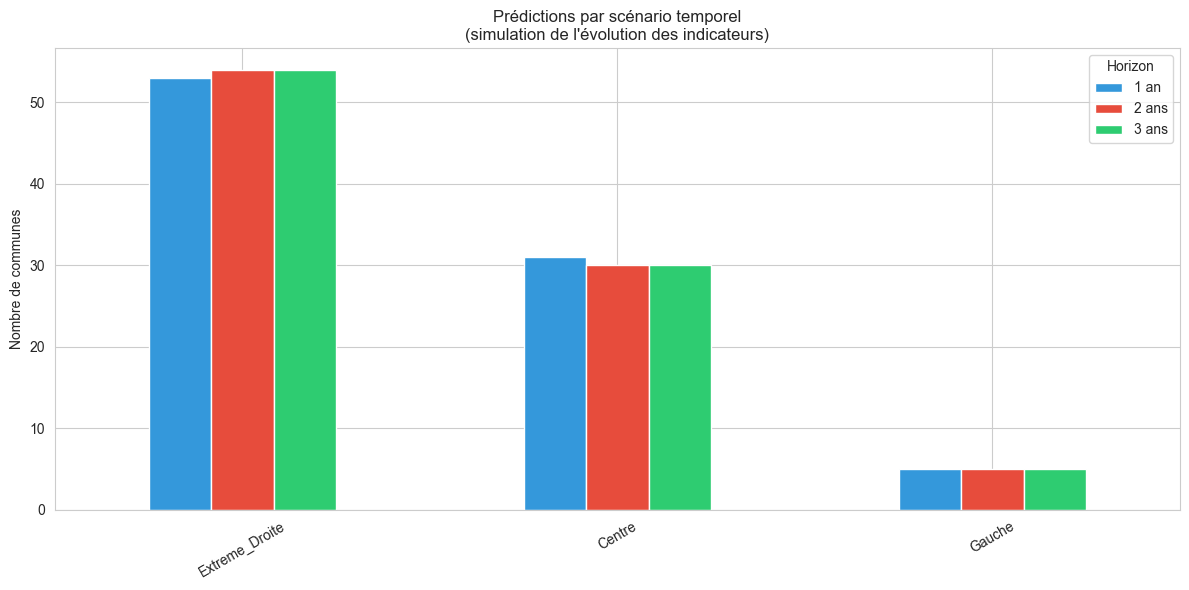

In [ ]:
# ============================================================
# ÉTAPE 8 : Scénarios prospectifs
# On fait varier les indicateurs socio-économiques pour simuler
# l'évolution à 1, 2 et 3 ans
# ============================================================
scenarios  = {}
variations = {'1 an': 0.05, '2 ans': 0.10, '3 ans': 0.15}

for horizon, pct in variations.items():
    X_scenario = X_test.copy() if meilleur_nom not in ['Logistic_Regression', 'KNN'] \
                 else X_test_scaled.copy()
    np.random.seed(42)
    noise              = np.random.uniform(-pct, pct, X_scenario.shape)
    X_scenario_modif   = X_scenario * (1 + noise)
    pred               = model_final.predict(X_scenario_modif)
    scenarios[horizon] = pd.Series(le.inverse_transform(pred)).value_counts()

# Visualiser
fig, ax = plt.subplots(figsize=(12, 6))
df_scenarios = pd.DataFrame(scenarios).fillna(0)
df_scenarios.plot(kind='bar', ax=ax,
                  color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Nombre de communes')
ax.set_title('Prédictions par scénario temporel\n(simulation de l\'évolution des indicateurs)')
ax.legend(title='Horizon')
plt.xticks(rotation=30)
plt.tight_layout()
# plt.savefig('graph_15_scenarios_prospectifs.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Export des prédictions du modèle final — PowerBI + DuckDB
# On prédit sur l'ensemble du dataset (train + test),
# on construit un tableau avec les infos utiles pour PowerBI
# et on le charge dans DuckDB comme table supplémentaire
# ============================================================
import pickle
import duckdb

# ── 1. Sauvegarder le modèle final ──────────────────────────
with open("best_model_classification.pkl", "wb") as f:
    pickle.dump(model_final, f)
print("Modèle sauvegardé : best_model_classification.pkl")

# ── 2. Prédictions sur l'ensemble du dataset ─────────────────
# On reconstruit X_full et y_full dans le même ordre
X_full        = pd.concat([X_train, X_test])
X_full_scaled = pd.concat([X_train_scaled, X_test_scaled])
y_full_true   = np.concatenate([y_train, y_test])

# Choisir données normalisées ou non selon le modèle
X_for_pred  = X_full_scaled if meilleur_nom in ["Logistic_Regression", "KNN"] else X_full
y_full_pred = model_final.predict(X_for_pred)

# Récupérer les codgeo dans le même ordre que X
codgeo_all = df.loc[X_full.index, "codgeo"].values

# ── 3. Construire le DataFrame de sortie ─────────────────────
df_export = pd.DataFrame({
    "codgeo":              codgeo_all,
    "bloc_reel":           le.inverse_transform(y_full_true),
    "bloc_predit":         le.inverse_transform(y_full_pred),
    "prediction_correcte": (y_full_true == y_full_pred).astype(int),
    "jeu":                 ["train"] * len(y_train) + ["test"] * len(y_test),
    "modele":              meilleur_nom,
    "accuracy_test":       round(acc_final, 4),
})

# ── 4. Ajouter les probabilités par classe ───────────────────
# Utile dans PowerBI pour faire des jauges de confiance
if hasattr(model_final, "predict_proba"):
    proba    = model_final.predict_proba(X_for_pred)
    df_proba = pd.DataFrame(
        proba,
        columns=[f"proba_{c}" for c in le.classes_],
        index=df_export.index
    )
    df_export             = pd.concat([df_export, df_proba], axis=1)
    df_export["confiance"] = proba.max(axis=1).round(4)
else:
    df_export["confiance"] = None

# ── 5. Enrichir avec libelle_commune depuis DuckDB ───────────
con        = duckdb.connect("warehouse.duckdb")
df_commune = con.execute("SELECT codgeo, libelle_commune FROM dim_commune").df()
df_commune["codgeo"] = df_commune["codgeo"].astype(str).str.zfill(5)
df_export["codgeo"]  = df_export["codgeo"].astype(str).str.zfill(5)
df_export            = df_export.merge(df_commune, on="codgeo", how="left")

# Réordonner : codgeo et libelle en premier
cols_first = ["codgeo", "bloc_reel", "bloc_predit",
              "prediction_correcte", "confiance", "jeu", "modele", "accuracy_test"]
cols_proba = [c for c in df_export.columns if c.startswith("proba_")]
df_export  = df_export[cols_first + cols_proba]

# ── 6. Export CSV pour PowerBI ───────────────────────────────
df_export.to_csv(
    "predictions_elections_classification.csv",
    index=False, sep=";", encoding="utf-8-sig"
)
print("CSV exporté : predictions_elections_classification.csv")

# ── 7. Chargement dans DuckDB ────────────────────────────────
con.register("_tmp_pred", df_export)
con.execute("""
    CREATE OR REPLACE TABLE fact_predictions_classification
    AS SELECT * FROM _tmp_pred
""")
con.close()
print("Table chargée dans DuckDB : fact_predictions_classification")

# ── 8. Résumé ────────────────────────────────────────────────
print(f"\n=== Résumé export ===")
print(f"  Communes totales  : {len(df_export)}")
print(f"  Dont train        : {(df_export['jeu'] == 'train').sum()}")
print(f"  Dont test         : {(df_export['jeu'] == 'test').sum()}")
print(f"  Prédictions OK    : {df_export['prediction_correcte'].sum()} / {len(df_export)}")
print(f"  Accuracy test     : {acc_final:.2%}")
print(f"  Modèle            : {meilleur_nom}")
print(f"\nAperçu :")
print(df_export.head(10).to_string(index=False))

Modèle sauvegardé : best_model_classification.pkl
CSV exporté : predictions_elections_classification.csv
Table chargée dans DuckDB : fact_predictions_classification

=== Résumé export ===
  Communes totales  : 267
  Dont train        : 178
  Dont test         : 89
  Prédictions OK    : 208 / 267
  Accuracy test     : 73.03%
  Modèle            : KNN

Aperçu :
codgeo      bloc_reel    bloc_predit  prediction_correcte  confiance   jeu modele  accuracy_test  proba_Centre  proba_Extreme_Droite  proba_Gauche
 69201 Extreme_Droite Extreme_Droite                    1     0.8018 train    KNN         0.7303      0.040800              0.801829      0.157371
 69047         Centre         Centre                    1     0.8223 train    KNN         0.7303      0.822279              0.154303      0.023418
 69181 Extreme_Droite Extreme_Droite                    1     0.7075 train    KNN         0.7303      0.239220              0.707470      0.053310
 69193         Centre         Centre              

## 9. Réponses aux indicateurs d'analyse

### Q1 : Quelle donnée est la plus corrélée aux résultats électoraux ?
→ Voir le graphique d'importance des features ci-dessus.  
La feature la plus importante est affichée en haut du classement.

### Q2 : Principe de l'apprentissage supervisé
L'apprentissage supervisé consiste à entraîner un algorithme sur un ensemble de données
où chaque observation possède des **variables explicatives** (features) et une **variable cible** (label).
Dans notre cas : X = indicateurs socio-économiques, y = bloc politique gagnant.

### Q3 : Comment mesurer la précision (accuracy) du modèle ?
`accuracy = (prédictions correctes) / (total des prédictions)`  
Évaluée sur un **jeu de test** non utilisé pendant l'entraînement (split 80/20).  
Confirmée par **cross-validation 5-fold** pour une estimation robuste.  
Notre seuil minimum est **0.5** (mieux que le hasard sur 4 classes = 0.25).